# 03 Macro IRFs

Replicate the Figure 2 local-projection sanity check: contractionary monetary policy lowers real activity and raises unemployment/interest rates in the expected direction.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import get_paths, ensure_output_dirs
paths = get_paths()
ensure_output_dirs(paths)
print('Project root:', PROJECT_ROOT)
print('Original root:', paths.original_root)

Project root: C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication
Original root: C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\replication_folder


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_analysis_panel
from src.local_projection import run_stacked_lp
from src.plots import savefig, paper_style
from src.metrics import write_table

panel = load_analysis_panel(paths)
macro_lagged = panel.copy()
macro_lagged['sh_rr_macro'] = macro_lagged['sh_rr'].shift(1)  # matches step402 temp_step102
macro_lagged['dUE'] = macro_lagged['UE'].diff()               # step402 plots dUE, not UE levels

# step402 estimates a broader set; the published combined Figure 2 uses these 12 panels.
cumulative_plot_vars = [
    ('dlnGDP', 'GDP', 'pct.'),
    ('dUE', 'Unemployment', 'pp'),
    ('dlnHousePrice', 'House price', 'pct.'),
    ('dlnConsumption', 'Consumption', 'pct.'),
    ('dlnDurables', 'Durables', 'pct.'),
    ('dlnNonDurables', 'Non-durables', 'pct.'),
    ('dlnServices', 'Services', 'pct.'),
    ('dlnBusinessIncome', 'Business income', 'pct.'),
    ('dlnWagesSalaries', 'Wages/salaries', 'pct.'),
    ('dlnFinancialIncome', 'Financial income', 'pct.'),
    ('dlnTransferIncome', 'Transfer income', 'pct.'),
]
auxiliary_step402_vars = ['dlnInvestment', 'dlnPGDP', 'dlnSP500', 'dlnHousePrice2']

raw_results = {
    var: run_stacked_lp(macro_lagged, var, shock_var='sh_rr_macro', cumulative=True)
    for var, _, _ in cumulative_plot_vars
}
for var in auxiliary_step402_vars:
    if var in macro_lagged.columns:
        raw_results[var] = run_stacked_lp(macro_lagged, var, shock_var='sh_rr_macro', cumulative=True)

raw_results['FFR'] = run_stacked_lp(panel, 'FFR', shock_var='sh_rr', cumulative=False)
if 'DGS10' in panel.columns:
    raw_results['DGS10'] = run_stacked_lp(panel, 'DGS10', shock_var='sh_rr', cumulative=False)

def step402_display_series(res, shifted_cumulative=False):
    if shifted_cumulative:
        h = res.horizons.copy()
        irf = np.r_[0.0, res.irf[:20]]
        se = np.r_[0.0, res.se[:20]]
    else:
        h = res.horizons
        irf = res.irf
        se = res.se
    return {
        'horizons': h,
        'irf': irf,
        'se': se,
        'lower_1se': irf - se,
        'upper_1se': irf + se,
        'lower_165se': irf - 1.65 * se,
        'upper_165se': irf + 1.65 * se,
        'pvalue': res.pvalue,
        'nobs': res.nobs,
        'covariance': res.covariance,
    }

plot_results = {
    var: step402_display_series(raw_results[var], shifted_cumulative=True)
    for var, _, _ in cumulative_plot_vars
}
plot_results['FFR'] = step402_display_series(raw_results['FFR'], shifted_cumulative=False)

summary_rows = []
for name, plotted in plot_results.items():
    summary_rows.append({
        'variable': name,
        'p_value': plotted['pvalue'],
        'nobs': plotted['nobs'],
        'peak_plotted_irf': float(np.nanmax(plotted['irf'])),
        'trough_plotted_irf': float(np.nanmin(plotted['irf'])),
        'h_peak_plotted': int(plotted['horizons'][np.nanargmax(plotted['irf'])]),
        'covariance': plotted['covariance'],
        'step402_display_shift': name != 'FFR',
    })
summary = pd.DataFrame(summary_rows)
write_table(summary, paths.tables / '03_macro_irf_summary.csv')
summary


,variable,p_value,nobs,peak_plotted_irf,trough_plotted_irf,h_peak_plotted,covariance,step402_display_shift
0,dlnGDP,2.531308e-13,2709,0.435804,-0.805701,20,driscoll-kraay,True
1,dUE,4.679270e-10,2709,0.259392,-0.351347,9,driscoll-kraay,True
2,dlnHousePrice,2.381896e-10,2583,0.000000,-6.950577,0,driscoll-kraay,True
3,dlnConsumption,1.528198e-10,2709,0.478888,-0.745190,20,driscoll-kraay,True
4,dlnDurables,1.004863e-12,2709,2.268173,-1.842530,20,driscoll-kraay,True
5,dlnNonDurables,2.163312e-04,2709,0.222490,-0.952188,5,driscoll-kraay,True
6,dlnServices,3.329892e-12,2709,0.000000,-0.778046,0,driscoll-kraay,True
7,dlnBusinessIncome,1.234030e-06,2709,0.000000,-4.258656,0,driscoll-kraay,True
8,dlnWagesSalaries,2.337019e-13,2709,1.186878,-0.480932,20,driscoll-kraay,True
9,dlnFinancialIncome,2.220446e-16,2709,1.955012,-1.141605,3,driscoll-kraay,True


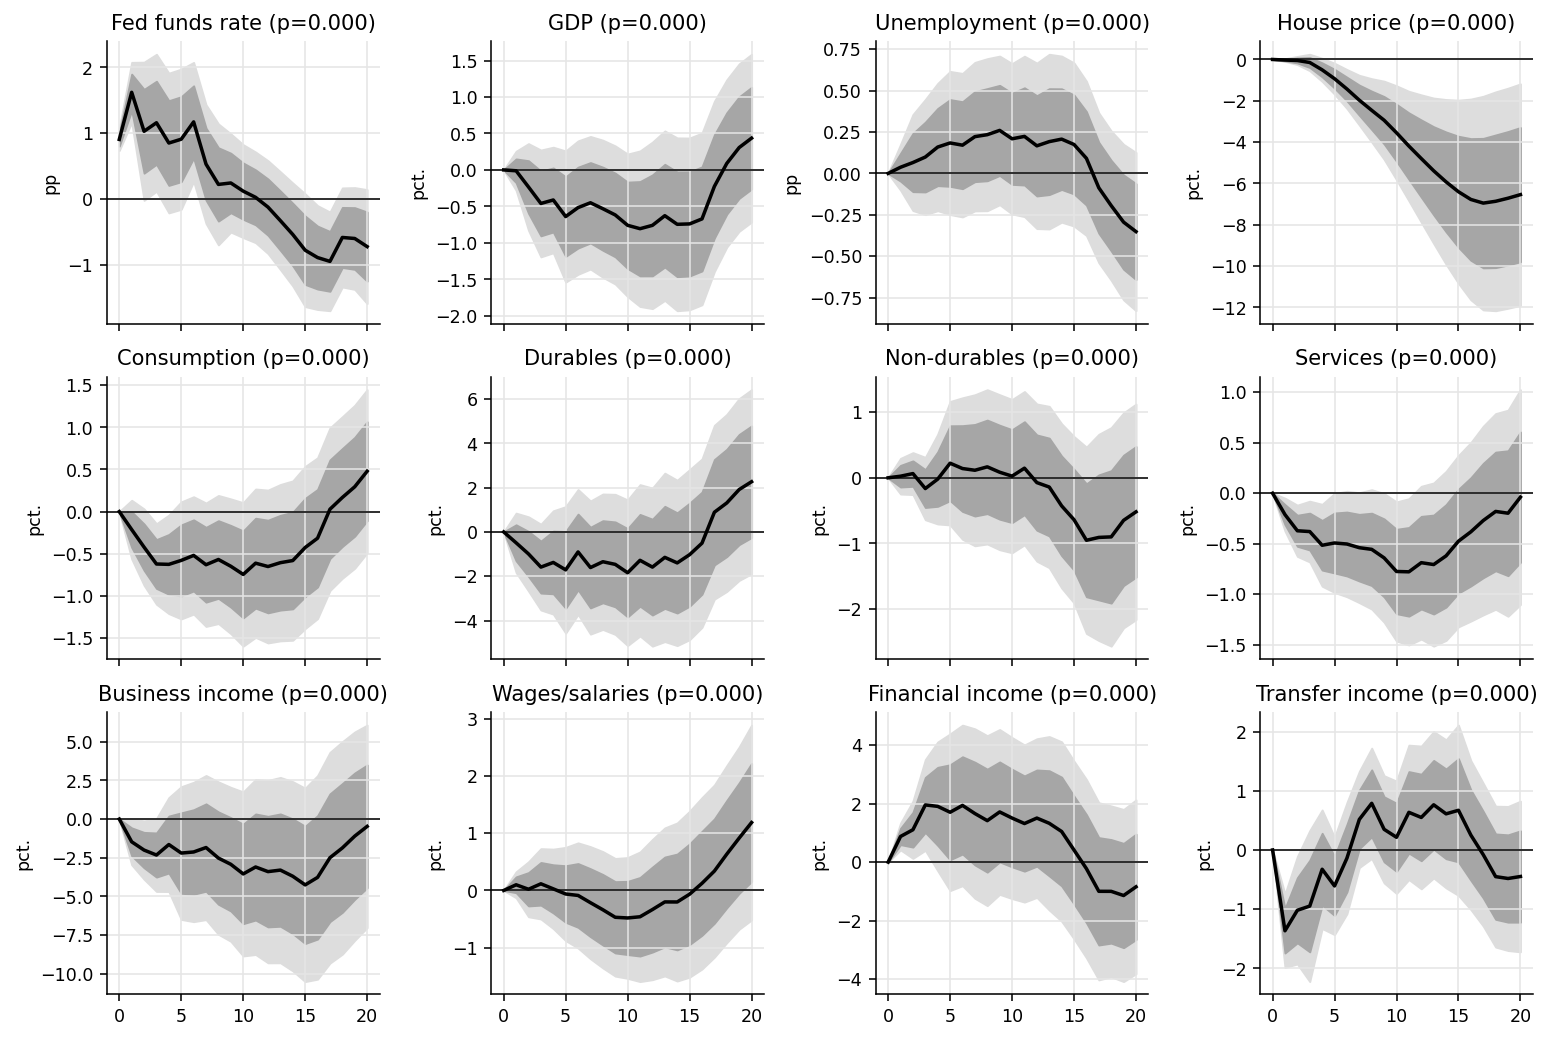

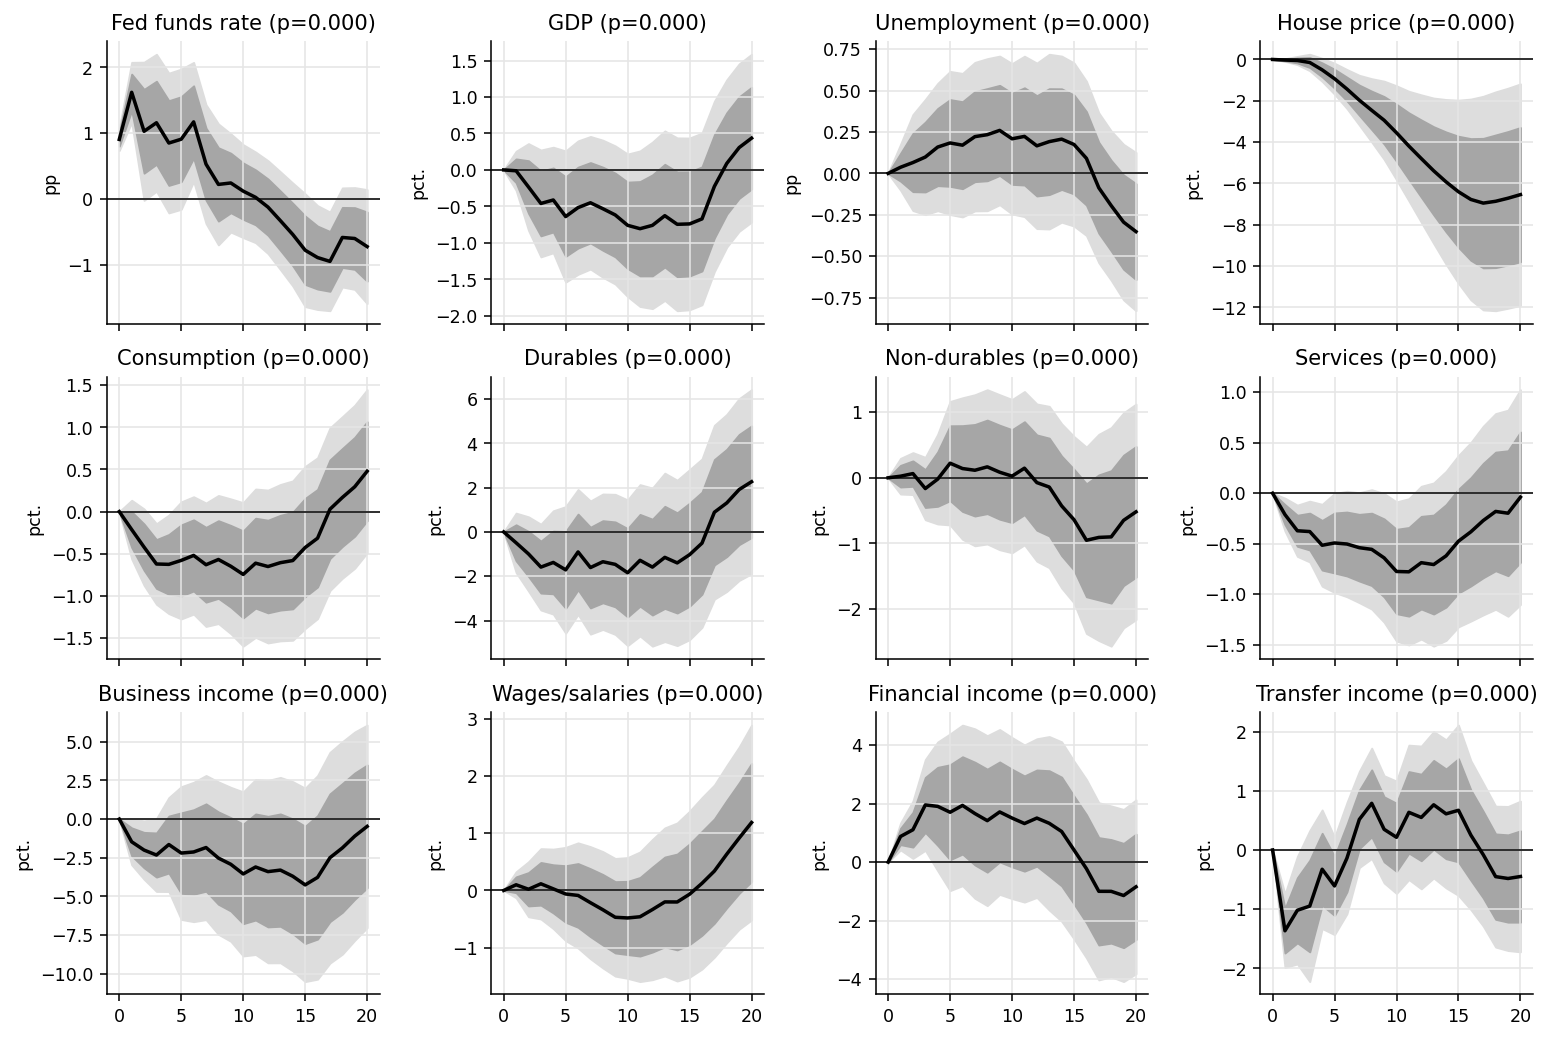

In [3]:
paper_style()
plot_vars = [
    ('FFR', 'Fed funds rate', 'pp'),
    ('dlnGDP', 'GDP', 'pct.'),
    ('dUE', 'Unemployment', 'pp'),
    ('dlnHousePrice', 'House price', 'pct.'),
    ('dlnConsumption', 'Consumption', 'pct.'),
    ('dlnDurables', 'Durables', 'pct.'),
    ('dlnNonDurables', 'Non-durables', 'pct.'),
    ('dlnServices', 'Services', 'pct.'),
    ('dlnBusinessIncome', 'Business income', 'pct.'),
    ('dlnWagesSalaries', 'Wages/salaries', 'pct.'),
    ('dlnFinancialIncome', 'Financial income', 'pct.'),
    ('dlnTransferIncome', 'Transfer income', 'pct.'),
]
fig, axes = plt.subplots(3, 4, figsize=(11, 7.5), sharex=True)
for ax, (var, title, ylabel) in zip(axes.ravel(), plot_vars):
    res = plot_results[var]
    h = res['horizons']
    ax.fill_between(h, res['lower_165se'], res['upper_165se'], color='#dddddd')
    ax.fill_between(h, res['lower_1se'], res['upper_1se'], color='#a6a6a6')
    ax.plot(h, res['irf'], color='black', lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{title} (p={res["pvalue"]:.3f})')
    ax.set_ylabel(ylabel)
savefig(fig, paths.figures / 'figure2_macro_irfs.png')
fig


## Deviation Note

This notebook now mirrors `step402`'s Figure 2 display convention more closely: real variables and unemployment use the one-quarter-lagged RR shock, the cumulative response is plotted with a zero at horizon 0, and the unemployment panel is `dUE` rather than unemployment in levels. The fed funds rate uses the contemporaneous shock and a non-cumulative response. `DGS10` and several auxiliary macro series are estimated for audit but are not included in the combined 12-panel figure because the published combined graph omits them.
